# Campus Café Orders – Data Visualization Lab

**Dataset**: Orders from a campus café in February 2025  
Columns: order_date, order_hour, drink_type, size, price, calories, sugars_g, caffeine_mg, customer_group

**Goal**: 
- Learn the basics of matplotlib, seaborn, and plotly
- Understand how to choose and create visualizations for different types of data and analysis goals.

---

## 0. Setup & Data Loading

Run this cell first.

In [1]:
import pandas as pd
import numpy as np

In [2]:
# Load the dataset
df = pd.read_csv('campus_cafe_orders.csv')
df['order_date'] = pd.to_datetime(df['order_date'])

In [3]:
print("Shape:", df.shape)
df.head(3)

Shape: (887, 11)


,order_id,order_datetime,order_date,order_hour,drink_type,size,price,calories,sugars_g,caffeine_mg,customer_group
0,1,2025-02-01 15:57:00,2025-02-01,15,Americano,Large,5.46,13,0.0,210,Faculty
1,2,2025-02-01 15:23:00,2025-02-01,15,Americano,Large,5.46,13,0.0,210,Student
2,3,2025-02-01 19:01:00,2025-02-01,19,Americano,Medium,4.20,10,0.0,150,Faculty


In [4]:
df.dtypes

order_id                   int64
order_datetime            object
order_date        datetime64[ns]
order_hour                 int64
drink_type                object
size                      object
price                    float64
calories                   int64
sugars_g                 float64
caffeine_mg                int64
customer_group            object
dtype: object

In [5]:
df['order_hour'] = df['order_hour'].astype('object')

In [6]:
quantitative_cols = df.select_dtypes(include='number').columns.to_list()
quantitative_cols.remove('order_id')

print(quantitative_cols)

['price', 'calories', 'sugars_g', 'caffeine_mg']


In [7]:
qualitative_cols = df.select_dtypes(exclude='number').columns.to_list()
qualitative_cols

['order_datetime',
 'order_date',
 'order_hour',
 'drink_type',
 'size',
 'customer_group']

## 1. Matplotlib – The Foundation

Matplotlib is the most fundamental plotting library in Python.

In [8]:
import matplotlib.pyplot as plt

`matplotlib.pyplot` (usually imported as `plt`) provides a simple interface similar to MATLAB.

It works like painting on a canvas:
- You create a **figure** (the whole page)
- You add **axes** (the plotting area)
- You draw lines, bars, points, text…
- You customize almost everything
- Finally call `plt.show()` 

**Problem**: Matplotlib requires you to prepare data yourself (lists, counts, etc.) → more code for simple tasks.

![matplotlib-hierarchy](https://raw.github.com/AUPP-Data-Science-Club/week4-data-visualization/blob/main/matplotlib-hierarchy.png)

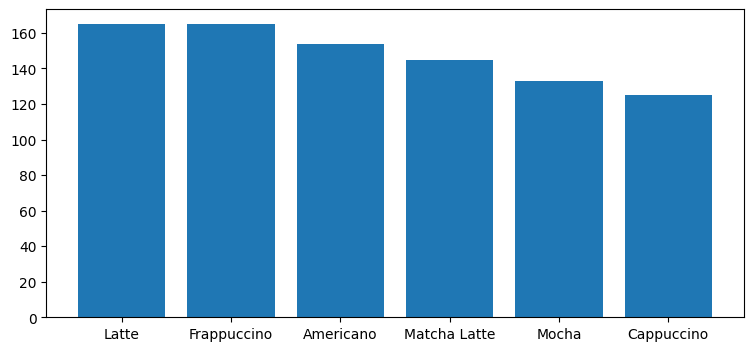

In [ ]:
# Example: Count of drink types with pure Matplotlib (a bit tedious)


## 2. Seaborn – Statistical plotting made easier

Seaborn is built **on top of Matplotlib**.

Advantages:
- Works directly with pandas DataFrames
- Beautiful default styles
- High-level functions for common statistical plots
- Less code for count plots, box plots, heatmaps, etc.
- You can still use Matplotlib commands to fine-tune (titles, labels, etc.)

→ Most people use **Seaborn + Matplotlib** together in real exploratory analysis.

In [10]:
import seaborn as sns

# **Univariate Analysis** 
### Qualitative (Categorical) data

C:\Users\Asus\AppData\Local\Temp\ipykernel_23764\3028665759.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  drink_type_countplot = sns.countplot(df, x='drink_type', edgecolor='black', lw=1.5, palette=palette)


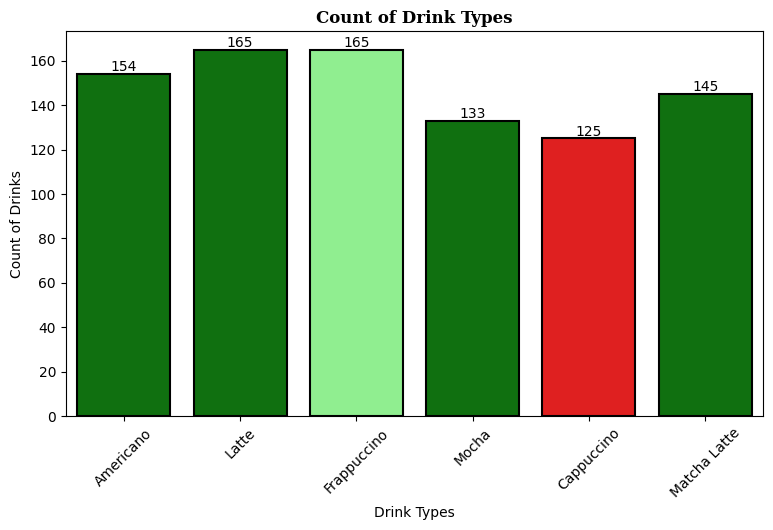

In [ ]:
# Seaborn countplot of drink_types – much simpler than pure Matplotlib


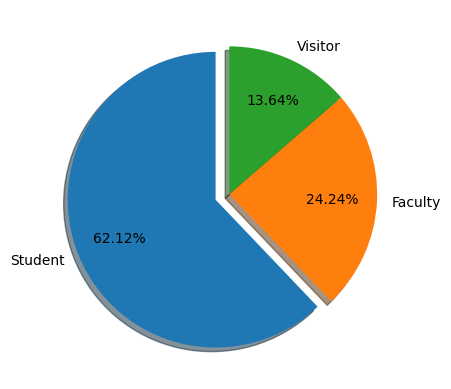

In [ ]:
# Pie chart (no direct seaborn equivalent → we use matplotlib)

# Proportion of customer groups


### Quantitative (Numerical) data

#### Distribution: Histogram, Boxplot

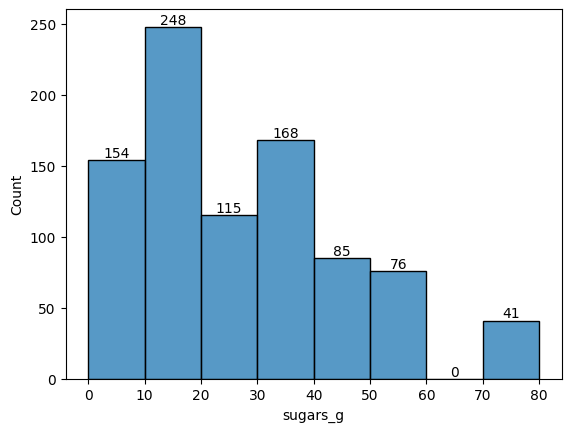

In [ ]:
# Histogram – distribution of sugars_mg


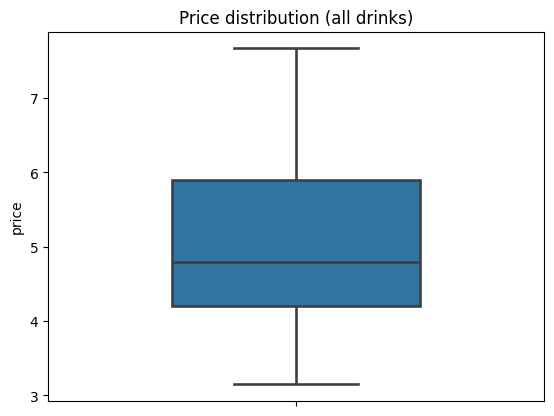

In [ ]:
# Boxplot of drink types: shows spread, median, outliers



### Working with mutiple axes in a figure

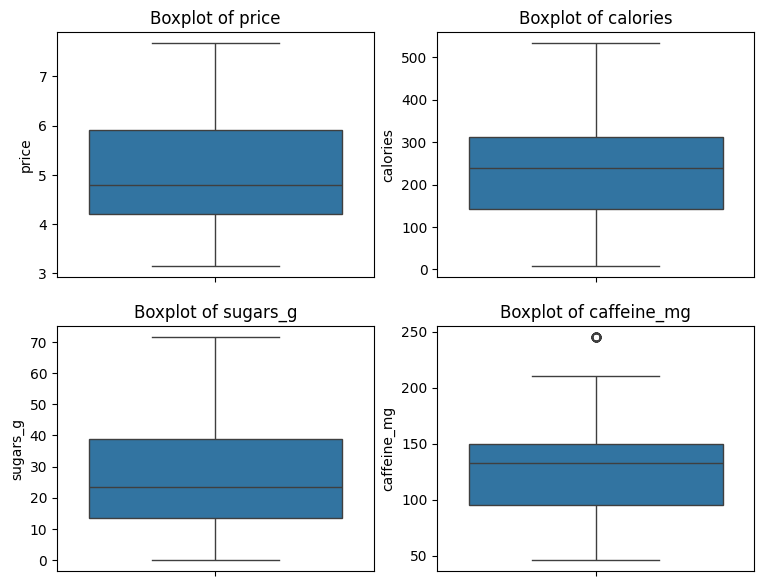

## 3. Bivariate Analysis

### Quantitative vs Quantitative: Correlation Matrix, Scatter Plot

In [ ]:
# Correlation matrix
print("Correlation between numerical columns:")


Correlation between numerical columns:


,price,calories,sugars_g,caffeine_mg
price,1.000000,0.747177,0.715324,0.431732
calories,0.747177,1.000000,0.983910,-0.027120
sugars_g,0.715324,0.983910,1.000000,-0.147456
caffeine_mg,0.431732,-0.027120,-0.147456,1.000000


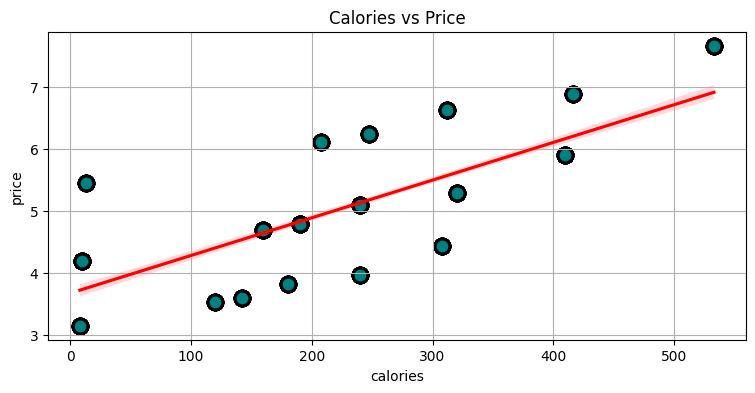

In [ ]:
# Scatter plot (Calories vs Price)


### Quantitative vs Qualitative: Grouped Boxplots

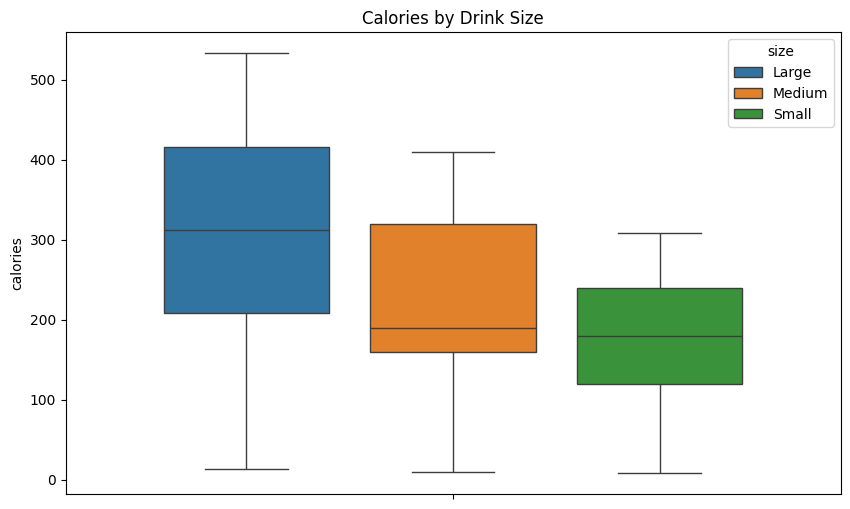

In [ ]:
# Grouped boxplot – calories by drink size


### Qualitative vs Qualitative: Stacked Bar Graph

In [ ]:
# Stacked bar chart: Customer group proportion by drink type

pivot = pd.crosstab(df['drink_type'], df['customer_group'], normalize='index')
pivot

customer_group,Faculty,Student,Visitor
drink_type,,,
Americano,0.415584,0.422078,0.162338
Cappuccino,0.384000,0.432000,0.184000
Frappuccino,0.054545,0.800000,0.145455
Latte,0.351515,0.515152,0.133333
Matcha Latte,0.027586,0.910345,0.062069
Mocha,0.240602,0.624060,0.135338


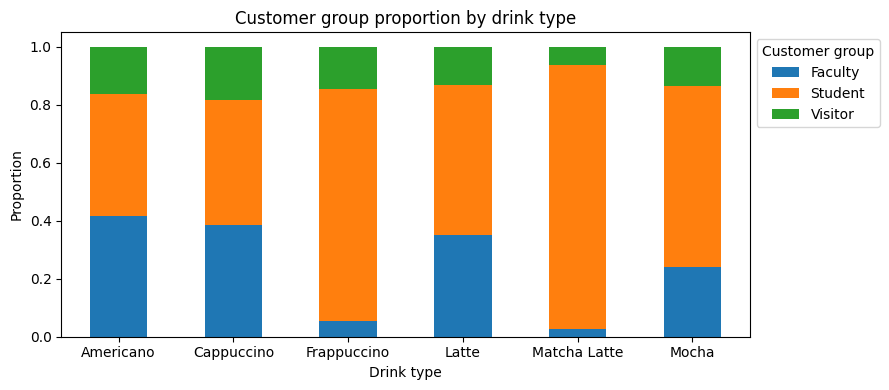

In [ ]:
# Stacked bar chart: Customer group proportion by drink type


## 4. Multivariate – Adding more dimensions

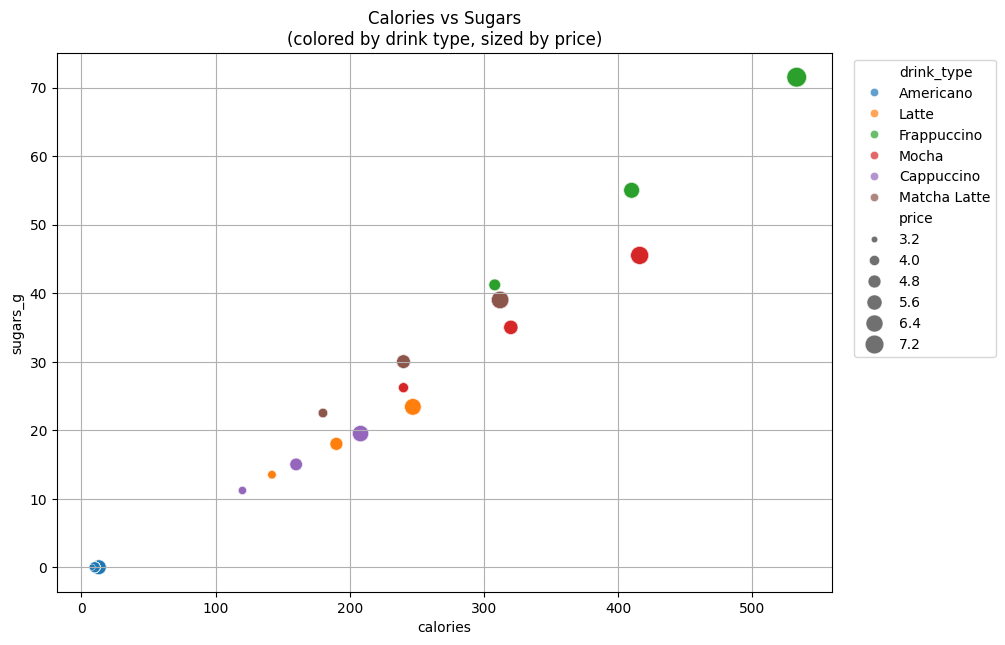

In [ ]:
# Scatter with color (hue) + size

plt.title("Calories vs Sugars\n(colored by drink type, sized by price)")

## 5. Time Series

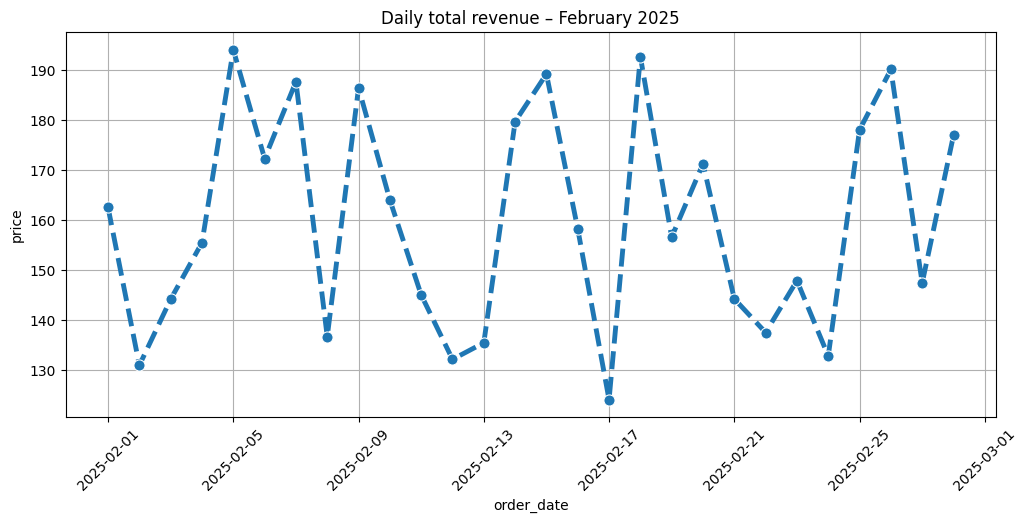

In [ ]:
# Daily total revenue (total price by order date)

daily = df.groupby('order_date')['price'].sum().reset_index()

## 6. Animation with Plotly

Plotly is great for interactive plots and animations.

We’ll create an animated bar race showing how the drink mix changes day by day.

In [24]:
import plotly.express as px

In [30]:
daily_drink = df.groupby(['order_date','drink_type']).size().reset_index(name='count')
daily_drink

,order_date,drink_type,count
0,2025-02-01,Americano,5
1,2025-02-01,Cappuccino,3
2,2025-02-01,Frappuccino,5
3,2025-02-01,Latte,9
4,2025-02-01,Matcha Latte,2
...,...,...,...
162,2025-02-28,Cappuccino,5
163,2025-02-28,Frappuccino,9
164,2025-02-28,Latte,9
165,2025-02-28,Matcha Latte,3


In [25]:
# Prepare data: count per drink per day
daily_drink = df.groupby(['order_date','drink_type']).size().reset_index(name='count')

fig = px.bar(
    daily_drink,
    x='drink_type',
    y='count',
    color='drink_type',
    animation_frame='order_date',
    animation_group='drink_type',
    range_y=[0, daily_drink['count'].max()*1.1],
    title="Drink orders per day – animated over February 2025",
    labels={'count':'Number of orders'},
    height=550
)

fig.update_layout(
    xaxis_title="Drink type",
    yaxis_title="Number of orders",
    showlegend=False
)

fig.show()